In [1]:
from llms.genserv.client import GenerationServiceClient
from evalserv_client import EvaluationServiceClient
from collections import Counter
from tasks import get_task
import json, time

eval_client = EvaluationServiceClient(base_url=f"http://localhost:5001")
assistant_gen_client = GenerationServiceClient(base_url=f"http://localhost:5000")

assistant_gen_client.load_model("microsoft/phi-4")

task_id = "sharded-HumanEval/76"
dataset_fn = "data/sharded_instructions_600.json"
with open(dataset_fn, "r") as f:
    data = json.load(f)

data = [d for d in data if d["task"] == "code"]
sample = [d for d in data if d["task_id"] == task_id][0]

task = get_task(sample["task"])

system_message = task.generate_system_prompt(sample)
input_prompt = task.populate_fully_specific_prompt(sample)

conversation = [{"role": "system", "content": system_message}, {"role": "user", "content": input_prompt}]
RESPONSES = {}

In [ ]:
def generate_responses(conversation, group_size):
    active_jobs, active_eval_jobs = [], []
    for i in range(group_size):
        job_result = assistant_gen_client.schedule_job(conversation, n_responses=1)
        active_jobs.append({"job_id": job_result["job_id"], "group_size": group_size, "response_index": i, "total_responses": group_size})

    responses = []
    eval_job_id2response = {}

    while active_jobs or active_eval_jobs:
        # print(len(active_jobs), len(active_eval_jobs))
        for job_info in active_jobs:
            job_result = assistant_gen_client.check_job(job_info["job_id"])
            if job_result["status"] == "completed":
                response = job_result["responses"][0]
                active_jobs.remove(job_info)
                this_conversation = conversation + [{"role": "assistant", "content": response["response_text"]}]
                eval_job_result = eval_client.schedule_evaluation(conversation=this_conversation, task_name=sample["task"], sample=sample)
                active_eval_jobs.append({"job_id": eval_job_result["job_id"]})
                eval_job_id2response[eval_job_result["job_id"]] = response
                responses.append(response)

        status_counts = Counter()
        for job_info in active_eval_jobs:
            job_result = eval_client.check_job(job_info["job_id"])
            status_counts[job_result["status"]] += 1
            if job_result["status"] == "completed" and "evaluation_return" in job_result["result"]:
                active_eval_jobs.remove(job_info)
                response = eval_job_id2response[job_info["job_id"]]
                response["score"] = job_result["result"]["evaluation_return"]["score"]
            elif job_result["status"] == "error" or (job_result["status"] == "completed" and "evaluation_return" not in job_result["result"]):
                active_eval_jobs.remove(job_info)
                response = eval_job_id2response[job_info["job_id"]]
                response["score"] = 0
        time.sleep(0.1)
    return responses

# Generate responses 50 at a time, up to 10000
RESPONSES["sampling"] = []
while len(RESPONSES["sampling"]) < 10000:
    print(f">>> Generating {len(RESPONSES["sampling"])} / 10000 responses")
    RESPONSES["sampling"] += generate_responses(conversation, 200)


>>> Generating 0 / 10000 responses
>>> Generating 200 / 10000 responses
>>> Generating 400 / 10000 responses
>>> Generating 600 / 10000 responses
>>> Generating 800 / 10000 responses
>>> Generating 1000 / 10000 responses
>>> Generating 1200 / 10000 responses
>>> Generating 1400 / 10000 responses
>>> Generating 1600 / 10000 responses


In [ ]:
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime
def generate_tree_responses(conversation, tree_depth, tree_degree):
    tree_job = assistant_gen_client.build_tree(conversation, depth=tree_depth, degree=tree_degree)
    tree_response = assistant_gen_client.wait_for_tree_completion(tree_job["job_id"])
    responses = tree_response["tree"]
    # print(f">>> {len(responses)} responses generated")

    eval_jobs = []
    for response in responses:
        eval_job = eval_client.schedule_evaluation(
            conversation=conversation + [{"role": "assistant", "content": response["response_text"]}], 
            task_name=sample["task"], 
            sample=sample
        )
        eval_jobs.append({"job_id": eval_job["job_id"], "response": response})
    
    # Wait for all evaluation jobs to complete
    pending_eval_jobs = eval_jobs.copy()
    while pending_eval_jobs:
        for eval_job_info in pending_eval_jobs[:]:
            eval_response = eval_client.check_job(eval_job_info["job_id"])
            if eval_response["status"] == "completed":
                eval_job_info["response"]["score"] = eval_response["result"]["evaluation_return"]["score"]
                pending_eval_jobs.remove(eval_job_info)
            elif eval_response["status"] == "error":
                eval_job_info["response"]["score"] = 0
                pending_eval_jobs.remove(eval_job_info)
        if pending_eval_jobs:
            time.sleep(0.1)
    return responses

for tree_depth in [7,8,9]:
    print(f"[{datetime.now()}] Generating tree responses for depth {tree_depth}")
    tree_key = f"tree_{tree_depth}"
    RESPONSES[tree_key] = []
    while len(RESPONSES[tree_key]) < 10000:
        print(f"[{datetime.now()}] Generating {len(RESPONSES[tree_key])} / 10000 tree responses")
        
        max_workers = 8
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [executor.submit(generate_tree_responses, conversation, tree_depth, 2) for _ in range(max_workers)]
            for future in futures:
                tree_responses = future.result()
                RESPONSES[tree_key] += tree_responses
    print(f"[{datetime.now()}] Finished generating tree responses for depth {tree_depth}")

>>> Generating 0 / 10000 tree responses
>>> 256 responses generated
>>> 256 responses generated
>>> 255 responses generated
>>> 255 responses generated
>>> 256 responses generated
>>> 256 responses generated
>>> 256 responses generated
>>> 255 responses generated
>>> Generating 2045 / 10000 tree responses
>>> 253 responses generated
>>> 253 responses generated
>>> 256 responses generated
>>> 255 responses generated
>>> 256 responses generated
>>> 256 responses generated
>>> 253 responses generated
>>> 256 responses generated
>>> Generating 4083 / 10000 tree responses
>>> 256 responses generated
>>> 256 responses generated
>>> 253 responses generated
>>> 242 responses generated
>>> 256 responses generated
>>> 256 responses generated
>>> 256 responses generated
>>> 254 responses generated
>>> Generating 6112 / 10000 tree responses
>>> 254 responses generated
>>> 250 responses generated
>>> 252 responses generated
>>> 256 responses generated
>>> 256 responses generated
>>> 255 responses g

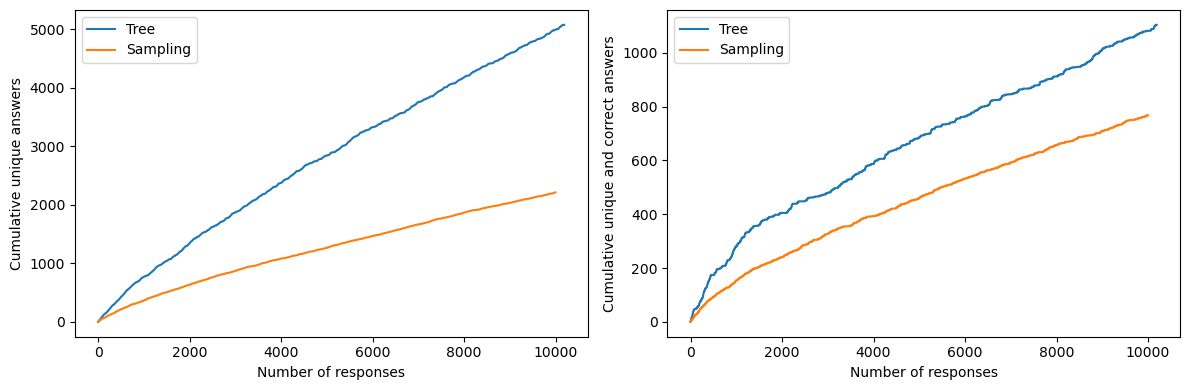

In [ ]:
from utils_unique import extract_answer, extract_answer2
from matplotlib import pyplot as plt

def calc_cumsum(responses, key="is_unique"):
    out_key = f"cumsum_{key}"
    cumulative_unique = []
    cumsum = 0
    for i in range(len(responses)):
        cumsum += responses[i][key]
        cumulative_unique.append(cumsum)
    return cumulative_unique

all_cumulatives = {}
for k in RESPONSES:
    answer_set = set()
    for r in RESPONSES[k]:
        r["answer"] = extract_answer2(r["response_text"])
        r["is_unique"] = 1 if r["answer"] not in answer_set else 0
        r["is_unique_and_correct"] = 1 if r["is_unique"] == 1 and r["score"] == 1 else 0
        answer_set.add(r["answer"])

    all_cumulatives[k] = {}
    all_cumulatives[k]["cumsum_unique"] = calc_cumsum(RESPONSES[k], key="is_unique")
    all_cumulatives[k]["cumsum_unique_and_correct"] = calc_cumsum(RESPONSES[k], key="is_unique_and_correct")


# plot both cumulative uniques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left subplot: cumulative unique
# ax1.plot(range(10000), range(10000), label="Linear")
for k in all_cumulatives:
    ax1.plot(range(len(all_cumulatives[k]["cumsum_unique"])), all_cumulatives[k]["cumsum_unique"], label=k)
ax1.set_xlabel("Number of responses")
ax1.set_ylabel("Cumulative unique answers")
ax1.legend()

# Right subplot: cumulative unique and correct
# ax2.plot(range(10000), range(10000), label="Linear")
for k in all_cumulatives:
    ax2.plot(range(len(all_cumulatives[k]["cumsum_unique_and_correct"])), all_cumulatives[k]["cumsum_unique_and_correct"], label=k)
ax2.set_xlabel("Number of responses")
ax2.set_ylabel("Cumulative unique and correct answers")
ax2.legend()

plt.tight_layout()
plt.show()


# Figure out if the backward is retrieving the right logprobs

In [ ]:
from backprop_worker import calculate_gradients_grpo, calculate_gradients_kto
from model_generator_hf import GenerationModel

assistant_model = GenerationModel(model_name="microsoft/phi-4")

In [ ]:
from backprop_worker import calculate_gradients_grpo, calculate_gradients_kto
import numpy as np

for op in backprop_ops[:10]:
    prefix_tokens = op["prefix"]
    branch_token_ids = [option["branch_tokens"][0] for option in op["options"]]
    expected_logprobs = [option["per_token_logprobs"] for option in op["options"]]
    advantages = [option["advantage"] for option in op["options"]]
    print("---------------")

    print(prefix_tokens, branch_token_ids, expected_logprobs)

    branch_logprobs = assistant_model.get_branch_logprobs(conversation, prefix_tokens, branch_token_ids, use_grad=False)
    print(branch_logprobs.tolist())
    print(advantages)
    loss = np.sum(np.array(advantages) * np.array(branch_logprobs.tolist()))
    print(">>> loss", loss)


---------------
[74694, 12958, 198, 755, 374, 31115, 21052, 2120, 11, 308, 997, 262] [471, 422] [[-2.628915786743164], [-0.11274780333042145]]
[-2.62890625, -0.1131591796875]
[-0.1467013888888889, 0.1467013888888889]
>>> loss 0.369063589307997
---------------
[74694, 12958, 198, 755, 374, 31115, 21052, 2120, 11, 308, 997, 262, 422] [865, 308] [[-2.0312657356262207], [-0.14064067602157593]]


[-2.03125, -0.140625]
[0.039930555555555525, -0.03993055555555558]
>>> loss -0.07549370659722215
---------------
[74694, 12958, 198, 755, 374, 31115, 21052, 2120, 11, 308, 997, 262, 422, 865] [624, 366, 2717] [[-0.6144652366638184], [-1.5435446500778198], [-1.5363411903381348]]
[-0.61181640625, -1.548828125, -1.548828125]
[0.6666666666666667, -0.3333333333333333, -0.3333333333333333]
>>> loss 0.6246744791666665
---------------
[74694, 12958, 198, 755, 374, 31115, 21052, 2120, 11, 308, 997, 262, 422, 308] [2717, 624, 334] [[-3.3442845344543457], [-0.06321928650140762], [-4.828166484832764]]
[-3.359375, -0.0626220703125, -4.8125]
[-0.2534722222222222, 0.5069444444444444, -0.2534722222222222]
>>> loss 2.039597405327691
---------------
[74694, 12958, 198, 755, 374, 31115, 21052, 2120, 11, 308, 997, 262, 422, 308, 624, 220, 16] [512, 323, 25] [[-0.44677799940109253], [-1.0563262701034546], [-4.493826389312744]]
[-0.44140625, -1.06640625, -4.50390625]
[-0.38541666666666663, 0.145833333333333

# Try the GRPO method

In [1]:
from backprop_worker import calculate_gradients_grpo, calculate_gradients_kto
from model_generator_hf import GenerationModel
import json, torch, numpy as np

def calc_model_improvements(responses, key="new_logprobs"):
    new_logprobs = assistant_model.get_logprobs(conversation, responses, use_grad=False)

    responses1_stats, responses0_stats = [], []
    for response, new_logprob in zip(responses, new_logprobs):
        response[key] = new_logprob.item()
        logprob_diff = response[key] - response["logprobs"]
        if response["score"] == 1:
            # we expect the logprob to go up, so positive diff
            change_rel = - logprob_diff / response["logprobs"]
            responses1_stats.append({"is_improvement": 1 if logprob_diff > 0 else 0, "change_abs": logprob_diff, "change_rel": change_rel})
        else:
            # we expect the logprob to go down, so negative diff
            change_rel = - logprob_diff / response["logprobs"]
            responses0_stats.append({"is_improvement": 0 if logprob_diff > 0 else 1, "change_abs": logprob_diff, "change_rel": change_rel})

    response_1_avg = {"is_improvement": np.mean([r["is_improvement"] for r in responses1_stats]), "change_abs": np.mean([r["change_abs"] for r in responses1_stats]), "change_rel": np.mean([r["change_rel"] for r in responses1_stats])}
    response_0_avg = {"is_improvement": np.mean([r["is_improvement"] for r in responses0_stats]), "change_abs": np.mean([r["change_abs"] for r in responses0_stats]), "change_rel": np.mean([r["change_rel"] for r in responses0_stats])}

    print("Succesful Responses Stats: ", response_1_avg)
    print("Failed Responses Stats: ", response_0_avg)
# fn = "test_responses.json"
fn = "tree_responses.json"
with open(fn, "r") as f:
    data = json.load(f)

responses = data["responses"]

already = set()
unique_responses = []
for response in responses:
    if response["response_text"] not in already:
        already.add(response["response_text"])
        unique_responses.append(response)

learning_rate = 5e-3

# assistant_model = GenerationModel(model_name="microsoft/phi-4")
# optimizer = torch.optim.SGD(assistant_model.model.parameters(), lr=learning_rate)


# print(f"unique_responses: {len(unique_responses)} / {len(responses)}")
# conversation = data["conversation"]

# optimizer.zero_grad()
# grad_return = calculate_gradients_grpo(assistant_model, conversation, unique_responses, {})

# torch.nn.utils.clip_grad_norm_(assistant_model.model.parameters(), max_norm=4.0)
# optimizer.step()

# calc_model_improvements(unique_responses, key="new_logprobs_grpo")

In [2]:
learning_rate = 5e-3

assistant_model, optimizer = None, None # reset
assistant_model = GenerationModel(model_name="microsoft/phi-4")
optimizer = torch.optim.SGD(assistant_model.model.parameters(), lr=learning_rate)

responses = data["responses"]
conversation = data["conversation"]

optimizer.zero_grad()
grad_return = calculate_gradients_kto(assistant_model, conversation, unique_responses, {})

torch.nn.utils.clip_grad_norm_(assistant_model.model.parameters(), max_norm=4.0)
optimizer.step()

calc_model_improvements(unique_responses, key="new_logprobs_kto")


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

[Backprop Worker] Found 83 backprop operations
[Backprop Worker] Backprop operation 1/83 completed
[Backprop Worker] Backprop operation 2/83 completed
[Backprop Worker] Backprop operation 3/83 completed
[Backprop Worker] Backprop operation 4/83 completed
[Backprop Worker] Backprop operation 5/83 completed
[Backprop Worker] Backprop operation 6/83 completed
[Backprop Worker] Backprop operation 7/83 completed
[Backprop Worker] Backprop operation 8/83 completed
[Backprop Worker] Backprop operation 9/83 completed
[Backprop Worker] Backprop operation 10/83 completed
[Backprop Worker] Backprop operation 11/83 completed
[Backprop Worker] Backprop operation 12/83 completed
[Backprop Worker] Backprop operation 13/83 completed
[Backprop Worker] Backprop operation 14/83 completed
[Backprop Worker] Backprop operation 15/83 completed
[Backprop Worker] Backprop operation 16/83 completed
[Backprop Worker] Backprop operation 17/83 completed
[Backprop Worker] Backprop operation 18/83 completed
[Backpro

OutOfMemoryError: CUDA out of memory. Tried to allocate 6.68 GiB. GPU 0 has a total capacity of 44.42 GiB of which 2.67 GiB is free. Including non-PyTorch memory, this process has 41.74 GiB memory in use. Of the allocated memory 35.84 GiB is allocated by PyTorch, and 5.58 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [5]:
import pandas as pd

dataset = [{"score": response["score"], "old_logprobs": response["logprobs"], "logprobs_grpo": response["new_logprobs_grpo"], "logprobs_kto": response["new_logprobs_kto"]} for response in unique_responses]
dataset = sorted(dataset, key=lambda x: x["old_logprobs"], reverse=True)
pd.DataFrame(dataset)

,score,old_logprobs,logprobs_grpo,logprobs_kto
0,1,-1.054326,-1.039062,-0.977539
1,0,-3.031322,-2.847656,-3.035156
2,1,-3.796802,-2.941406,-3.753906
3,1,-3.825805,-3.113281,-3.783203
4,1,-4.632554,-4.203125,-4.437500
5,1,-4.758059,-4.113281,-4.445312
6,0,-5.139640,-6.726562,-7.007812
7,1,-5.648803,-5.292969,-5.312500
8,0,-5.971815,-7.640625,-7.843750
9,0,-5.975878,-6.492188,-8.953125
